# AO3 Fandom Category Atlas: 分类分析

这个 notebook 是项目 **AO3 Fandom Category Atlas** 的分析入口，用于统计 `ao3_jujutsu_comments_tags.xlsx` 中不同 `fandoms` 的 `icon_category_text` 类别构成，并输出图表和 CSV 汇总。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.rcParams['figure.dpi'] = 140
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', font='Microsoft YaHei')

In [2]:
DATA_PATH = Path('output/ao3_jujutsu_comments_tags.xlsx')
OUTPUT_DIR = Path('output/icon_category_analysis')
TOP_N_FANDOMS = 12

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_PATH, OUTPUT_DIR

(WindowsPath('output/ao3_jujutsu_comments_tags.xlsx'),
 WindowsPath('output/icon_category_analysis'))

In [3]:
df = pd.read_excel(DATA_PATH)
df = df[['work_id', 'title', 'fandoms', 'icon_category_text']].copy()

df['fandoms'] = df['fandoms'].fillna('Missing').astype(str).str.strip()
df['icon_category_text'] = df['icon_category_text'].fillna('No category').astype(str)
df['category_list'] = (
    df['icon_category_text']
    .str.split(',')
    .apply(lambda values: [value.strip() for value in values if str(value).strip()])
)
df['category_count_per_work'] = df['category_list'].str.len()

df.head()

,work_id,title,fandoms,icon_category_text,category_list,category_count_per_work
0,5702212,狱门调教（1——4）,Shingeki no Kyojin | Attack on Titan,M/M,[M/M],1
1,49265002,A-Z Female Collection,RWBY | 僕のヒーローアカデミア | Boku no Hero Academia | M...,"F/M, Multi, M/M","[F/M, Multi, M/M]",3
2,20512595,To Sing a Song of Steel,Shingeki no Kyojin | Attack on Titan,F/M,[F/M],1
3,1223362,He Chose Titans,Shingeki no Kyojin | Attack on Titan,M/M,[M/M],1
4,32192446,Monsters Are Made (Not Born),Naruto | Shingeki no Kyojin | Attack on Titan,Gen,[Gen],1


## 统计口径说明

下面的主要占比分析基于 `icon_category_text` 拆分后的类别标签。也就是说，如果一条作品同时属于 `F/M, Multi, M/M`，它会同时给这 3 个 category 各贡献 1 次计数，因此这里统计的是“类别出现次数占比”，不是“作品唯一占比”。

In [4]:
category_long = (
    df[['work_id', 'title', 'fandoms', 'category_list']]
    .explode('category_list')
    .rename(columns={'category_list': 'category'})
)
category_long['category'] = category_long['category'].fillna('No category')

print('作品数:', len(df))
print('拆分后 category 记录数:', len(category_long))
category_long.head()

作品数: 760
拆分后 category 记录数: 1086


,work_id,title,fandoms,category
0,5702212,狱门调教（1——4）,Shingeki no Kyojin | Attack on Titan,M/M
1,49265002,A-Z Female Collection,RWBY | 僕のヒーローアカデミア | Boku no Hero Academia | M...,F/M
1,49265002,A-Z Female Collection,RWBY | 僕のヒーローアカデミア | Boku no Hero Academia | M...,Multi
1,49265002,A-Z Female Collection,RWBY | 僕のヒーローアカデミア | Boku no Hero Academia | M...,M/M
2,20512595,To Sing a Song of Steel,Shingeki no Kyojin | Attack on Titan,F/M


In [5]:
overall_counts = category_long['category'].value_counts().rename_axis('category').reset_index(name='count')
overall_counts['share'] = overall_counts['count'] / overall_counts['count'].sum()
overall_counts

,category,count,share
0,M/M,410,0.377532
1,F/M,237,0.218232
2,Gen,236,0.217311
3,Multi,86,0.079190
4,F/F,69,0.063536
5,Other,27,0.024862
6,No category,21,0.019337


In [6]:
fandom_counts = df['fandoms'].value_counts().rename_axis('fandoms').reset_index(name='work_count')
top_fandoms = fandom_counts.head(TOP_N_FANDOMS)['fandoms'].tolist()
fandom_counts.head(TOP_N_FANDOMS)

,fandoms,work_count
0,Haikyuu!!,60
1,原神 | Genshin Impact (Video Game),59
2,僕のヒーローアカデミア | Boku no Hero Academia | My Hero ...,56
3,One Piece,51
4,Naruto,50
5,SPY x FAMILY (Manga) | SPY x FAMILY (Anime),48
6,Shingeki no Kyojin | Attack on Titan,48
7,Hunter X Hunter,39
8,呪術廻戦 | Jujutsu Kaisen (Manga) | 呪術廻戦 | Jujutsu...,36
9,Chainsaw Man (Manga) | Chainsaw Man (Anime),30


In [7]:
fandom_category_counts = (
    category_long[category_long['fandoms'].isin(top_fandoms)]
    .groupby(['fandoms', 'category'])
    .size()
    .rename('count')
    .reset_index()
)

fandom_category_counts['share_within_fandom'] = (
    fandom_category_counts['count']
    / fandom_category_counts.groupby('fandoms')['count'].transform('sum')
)

fandom_category_table = fandom_category_counts.pivot(
    index='fandoms',
    columns='category',
    values='share_within_fandom'
).fillna(0)

fandom_order = fandom_counts.set_index('fandoms').loc[top_fandoms].sort_values('work_count', ascending=False).index
fandom_category_table = fandom_category_table.loc[fandom_order]
fandom_category_table

category,F/F,F/M,Gen,M/M,Multi,No category,Other
fandoms,,,,,,,
Haikyuu!!,0.014925,0.029851,0.059701,0.880597,0.014925,0.000000,0.000000
原神 | Genshin Impact (Video Game),0.103896,0.181818,0.064935,0.584416,0.038961,0.000000,0.025974
僕のヒーローアカデミア | Boku no Hero Academia | My Hero Academia,0.032609,0.163043,0.347826,0.315217,0.097826,0.043478,0.000000
One Piece,0.086957,0.086957,0.318841,0.405797,0.072464,0.028986,0.000000
Naruto,0.094737,0.252632,0.157895,0.221053,0.210526,0.042105,0.021053
SPY x FAMILY (Manga) | SPY x FAMILY (Anime),0.000000,0.746032,0.253968,0.000000,0.000000,0.000000,0.000000
Shingeki no Kyojin | Attack on Titan,0.046875,0.250000,0.140625,0.515625,0.031250,0.000000,0.015625
Hunter X Hunter,0.000000,0.097561,0.146341,0.756098,0.000000,0.000000,0.000000
呪術廻戦 | Jujutsu Kaisen (Manga) | 呪術廻戦 | Jujutsu Kaisen (Anime),0.063830,0.063830,0.106383,0.659574,0.021277,0.042553,0.042553


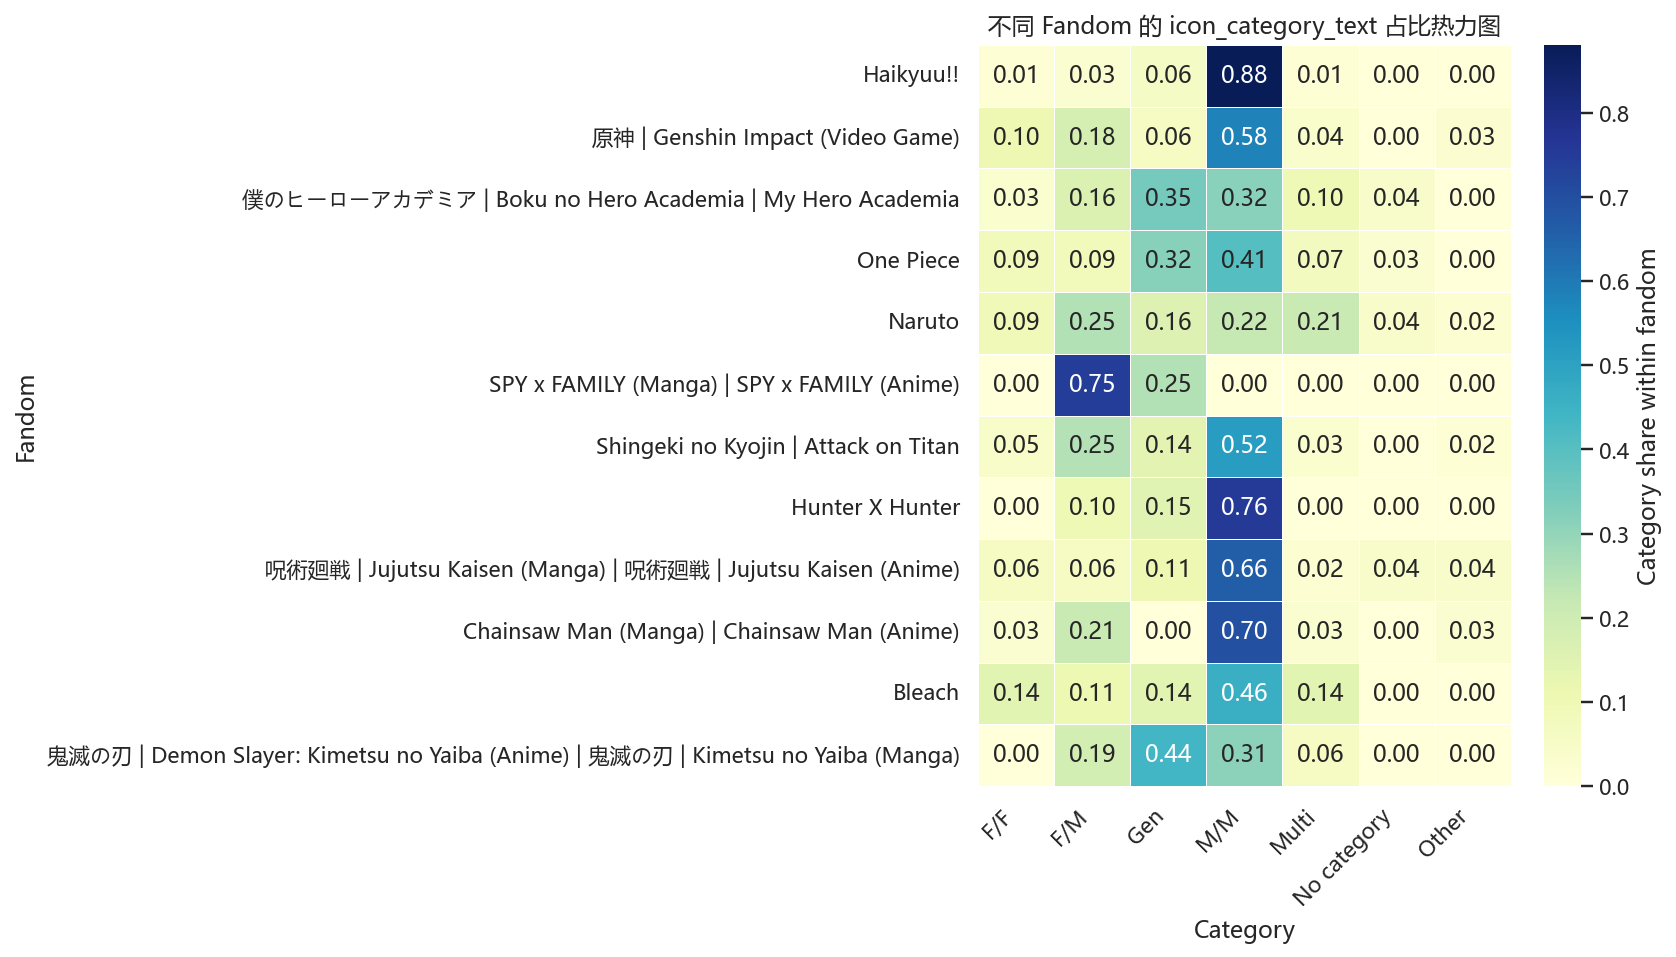

WindowsPath('output/icon_category_analysis/fandom_category_heatmap.png')

In [8]:
heatmap_fig = plt.figure(figsize=(12, 7))
ax = sns.heatmap(
    fandom_category_table,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': 'Category share within fandom'}
)
ax.set_title('不同 Fandom 的 icon_category_text 占比热力图')
ax.set_xlabel('Category')
ax.set_ylabel('Fandom')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
heatmap_path = OUTPUT_DIR / 'fandom_category_heatmap.png'
plt.savefig(heatmap_path, bbox_inches='tight')
plt.show()
heatmap_path

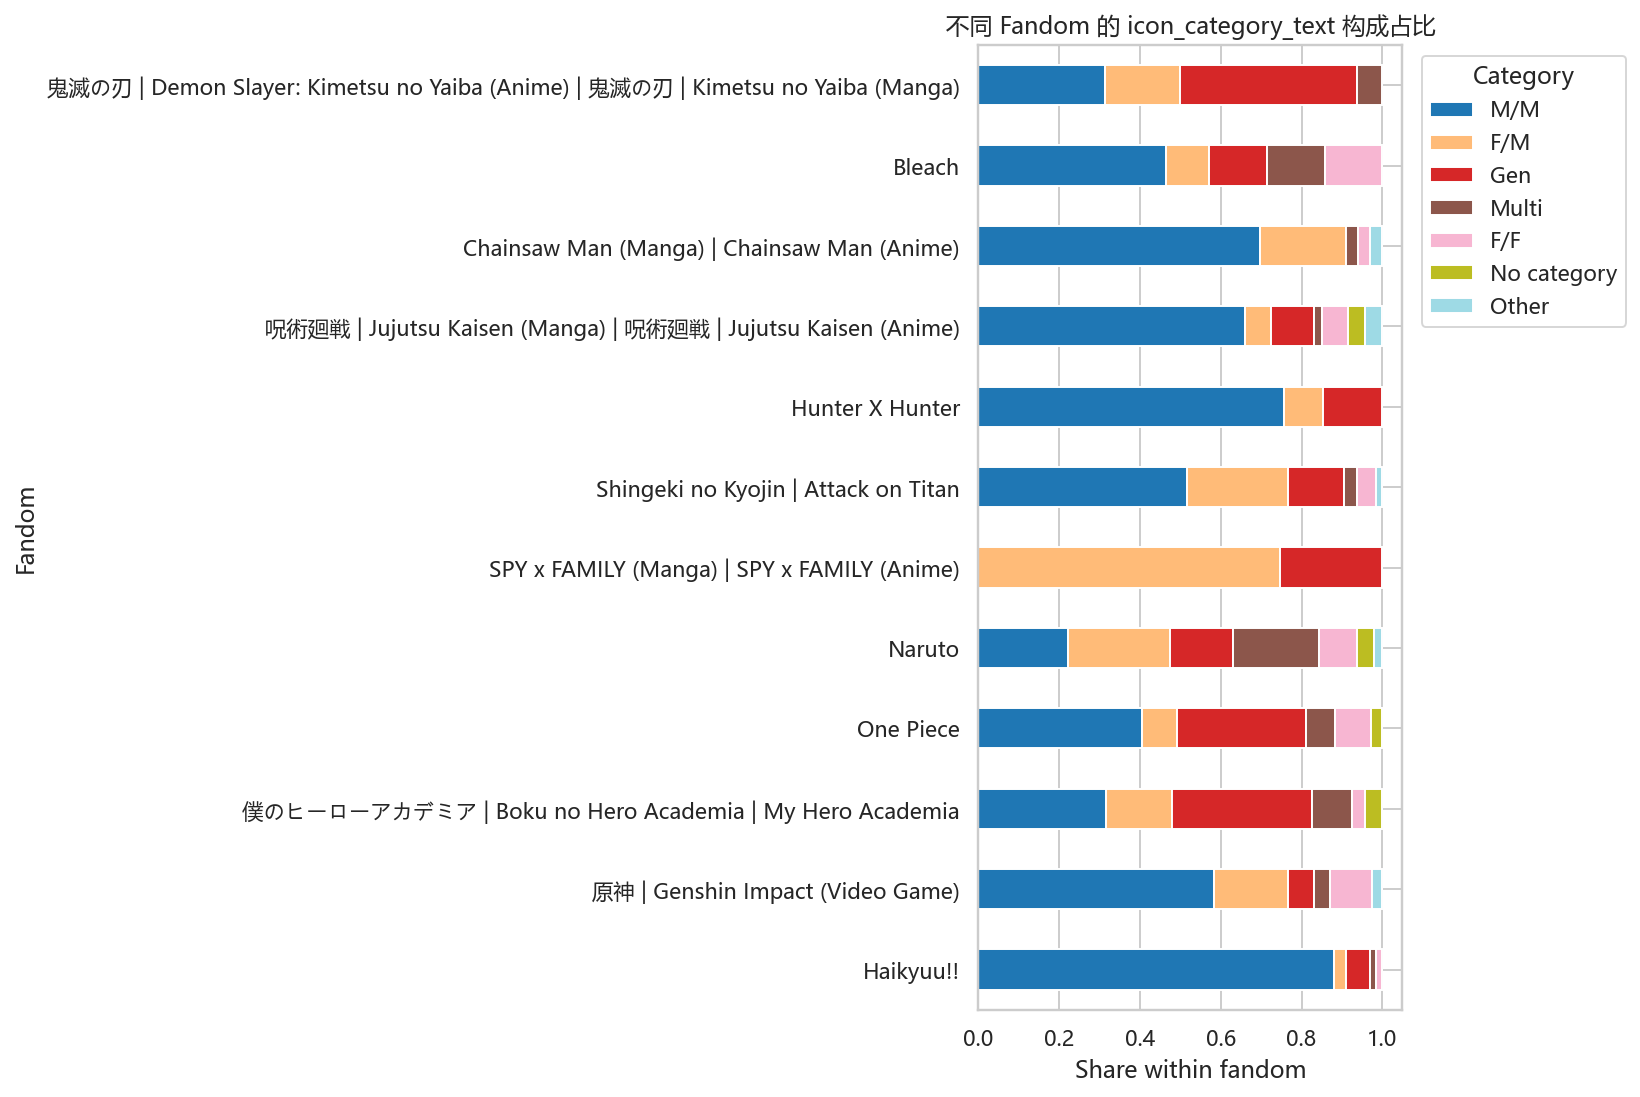

WindowsPath('output/icon_category_analysis/fandom_category_stacked_bar.png')

In [9]:
stacked_data = fandom_category_table.copy()
stacked_data = stacked_data[stacked_data.sum(axis=0).sort_values(ascending=False).index]

stacked_fig = stacked_data.plot(
    kind='barh',
    stacked=True,
    figsize=(12, 8),
    colormap='tab20'
)
stacked_fig.set_title('不同 Fandom 的 icon_category_text 构成占比')
stacked_fig.set_xlabel('Share within fandom')
stacked_fig.set_ylabel('Fandom')
stacked_fig.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
stacked_path = OUTPUT_DIR / 'fandom_category_stacked_bar.png'
plt.savefig(stacked_path, bbox_inches='tight')
plt.show()
stacked_path

## 可选补充：按作品口径统计

如果你想看“某个 fandom 中，有多少比例的作品包含某个 category”，可以用下面这个版本。这里的分母是作品数，不是拆分后的 category 数，因此更适合回答作品覆盖率问题。

In [10]:
work_level_share = (
    category_long[category_long['fandoms'].isin(top_fandoms)]
    .drop_duplicates(['work_id', 'fandoms', 'category'])
    .groupby(['fandoms', 'category'])
    .size()
    .rename('work_count_with_category')
    .reset_index()
    .merge(fandom_counts, on='fandoms', how='left')
)

work_level_share['share_of_works'] = (
    work_level_share['work_count_with_category'] / work_level_share['work_count']
)
work_level_share.sort_values(['fandoms', 'share_of_works'], ascending=[True, False]).head(20)

,fandoms,category,work_count_with_category,work_count,share_of_works
3,Bleach,M/M,10,19,0.526316
2,Bleach,Gen,4,19,0.210526
0,Bleach,F/F,3,19,0.157895
4,Bleach,Multi,3,19,0.157895
1,Bleach,F/M,2,19,0.105263
7,Chainsaw Man (Manga) | Chainsaw Man (Anime),M/M,13,30,0.433333
6,Chainsaw Man (Manga) | Chainsaw Man (Anime),F/M,4,30,0.133333
5,Chainsaw Man (Manga) | Chainsaw Man (Anime),F/F,1,30,0.033333
8,Chainsaw Man (Manga) | Chainsaw Man (Anime),Multi,1,30,0.033333
9,Chainsaw Man (Manga) | Chainsaw Man (Anime),Other,1,30,0.033333


In [11]:
overall_counts.to_csv(OUTPUT_DIR / 'overall_category_share.csv', index=False, encoding='utf-8-sig')
fandom_counts.to_csv(OUTPUT_DIR / 'fandom_work_counts.csv', index=False, encoding='utf-8-sig')
fandom_category_counts.to_csv(OUTPUT_DIR / 'fandom_category_share_long.csv', index=False, encoding='utf-8-sig')
fandom_category_table.reset_index().to_csv(OUTPUT_DIR / 'fandom_category_share_wide.csv', index=False, encoding='utf-8-sig')
work_level_share.to_csv(OUTPUT_DIR / 'fandom_category_share_by_work.csv', index=False, encoding='utf-8-sig')

print('已导出到:', OUTPUT_DIR.resolve())

已导出到: F:\Desktop\scrapy-master\src\output\icon_category_analysis
